# Pipeline de propensión al cambio bancario — Santander CX (Fase 1)

Predecimos **propensión al cambio de banco** a partir de una encuesta de 300 clientes mexicanos.

> ⚠️ **La etiqueta `Y` es sintética.** No existe dato real de quién se cambió de banco. `Y` se
> construye a partir de las propias respuestas siguiendo un score de riesgo justificado (NPS +
> Kano). **El modelo aprende a reproducir una *definición* de riesgo, no un churn observado.** El
> valor del trabajo está en la metodología de scoring, no en una capacidad predictiva probada
> contra deserción real.

El notebook está organizado en secciones numeradas; cada una abre con una nota breve de *qué*
hace y *por qué*.

## 0. Configuración

Todas las constantes viven aquí arriba, comentadas y fáciles de modificar: rutas, semilla, mapeo
de columnas, los pesos del target (`TRUST_POINTS`, `KANO_WEIGHTS`), el umbral de riesgo y los
órdenes ordinales.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             f1_score, precision_score, recall_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibrationDisplay
from xgboost import XGBClassifier
import shap

# --- Rutas y semilla ---------------------------------------------------------
# Ruta al CSV: portable — funciona desde la raíz del repo o desde ML_Pipeline/
from pathlib import Path
_CSV = "encuesta_preferencia_entidades_financieras.csv"
_CANDIDATES = [Path("data") / _CSV, Path("ML_Pipeline/data") / _CSV, Path("../data") / _CSV]
DATA_PATH = str(next((p for p in _CANDIDATES if p.exists()), _CANDIDATES[0]))
RANDOM_STATE = 42

# --- Renombrado a snake_case (posicional: 21 columnas del Google Form) --------
SNAKE_COLUMNS = [
    "marca_temporal", "age", "income", "n_apps", "knows_fintech", "inst_type",
    "fintechs_used", "fintech_concerns", "prefer_fintech", "diff_uses", "main_factor",
    "transaction_difficulty", "app_frustrations", "app_likes", "support_pref",
    "trust_level", "security_concerns", "main_bank", "switch_reasons",
    "benefits_valued", "branch_importance",
]

# --- Componente 1 del target: puntos de confianza graduados estilo NPS --------
TRUST_POINTS = {
    1: 2.5,   # detractor profundo: dispara prácticamente solo
    2: 2.5,   # detractor sólido:   dispara prácticamente solo
    3: 1.0,   # detractor débil:    contribuye, vulnerable, no dispara solo
    4: 0.0,   # pasivo:             neutral
    5: -1.0,  # promotor:           descuento por lealtad (reduce falsos positivos)
}

# --- Componente 2 del target: Índice de Fuga ponderado por Modelo Kano --------
KANO_WEIGHTS = {
    # Must-Be (ruptura) — 2.0
    "Mala experiencia con mi banco actual": 2.0,
    "Cargo de comisiones que no aplican": 2.0,
    "Que no me solucione problemas": 2.0,
    "Que cuenten SIEMPRE con un telefono con atencion personal ( no chatbots)": 2.0,
    # Performance financiero — 1.5
    "Comisiones más bajas": 1.5,
    "Mejores tasas": 1.5,
    "Mejores créditos": 1.5,
    "Límites transaccionales y monto máximo en la cuenta": 1.5,
    # Performance operativo — 1.25
    "Mejor app": 1.25,
    "Mejor atención": 1.25,
    "Mejor ubicación de cajeros": 1.25,
    # Delighter (aspiracional) — 0.8
    "Recompensas más atractivas": 0.8,
    "Costo beneficio entre seguridad y rendimiento": 0.8,
    # Influencia externa — 0.5
    "Recomendación cercana": 0.5,
    # Lealtad / indiferente — 0.0
    "Nada": 0.0, "Nada, estoy muy agusto": 0.0, "No cambiaría": 0.0,
    "Necesidad de abrir otra cuenta": 0.0, "O": 0.0,
}

RISK_THRESHOLD = 2.75   # umbral único del score compuesto (justificado en la sección 3)

# --- Órdenes ordinales explícitos --------------------------------------------
AGE_ORDER = ["18-25", "26-40", "41-55", "56+"]
INCOME_ORDER = ["Menos de $10,000 MXN", "$10,000MXN–$20,000MXN",
                "$20,000MXN–$50,000MXN", "Más de $50,000MXN"]

# --- Listas de features finales (16) -----------------------------------------
NUMERIC_FEATURES = ["n_fintech_concerns", "n_app_frustrations", "n_app_likes",
                    "n_security_concerns", "n_benefits_valued", "n_apps",
                    "transaction_difficulty", "branch_importance", "uses_fintech"]
ORDINAL_FEATURES = ["age", "income"]
CATEGORICAL_FEATURES = ["knows_fintech", "inst_type", "prefer_fintech",
                        "support_pref", "main_bank"]
FEATURES = NUMERIC_FEATURES + ORDINAL_FEATURES + CATEGORICAL_FEATURES

sns.set_style("whitegrid")

## 1. Funciones helper

Definidas **una sola vez** aquí para que las celdas de abajo queden cortas y legibles. Cada una
lleva un docstring de una línea.

In [2]:
def split_multi(s):
    """Separa una celda multi-select por ';' y devuelve lista limpia ([] si NaN/vacío)."""
    if pd.isna(s) or str(s).strip() == "":
        return []
    return [tok.strip() for tok in str(s).split(";") if tok.strip()]

def kano_index(reasons):
    """Suma los pesos Kano de las razones de cambio (razón no listada = 0.0)."""
    return sum(KANO_WEIGHTS.get(r, 0.0) for r in reasons)

def risk_score(trust, if_score):
    """Score compuesto = puntos NPS de confianza + Índice de Fuga ponderado por Kano."""
    return TRUST_POINTS[trust] + if_score

def nps_band(trust):
    """Etiqueta el tramo NPS-equivalente de un valor de confianza 1-5."""
    return {1: "Detractor profundo", 2: "Detractor sólido", 3: "Detractor débil",
            4: "Pasivo", 5: "Promotor"}[trust]

def count_multi(series):
    """Cuenta de ítems marcados en una columna multi-select."""
    return series.apply(lambda s: len(split_multi(s)))

## 2. Carga y limpieza de tipos

Leemos el CSV exportado de Google Forms (encabezados en español largo), renombramos a snake_case
y arreglamos los tipos:

- `n_apps`: viene como texto con `"4 o más"` → lo convertimos a `4` y a numérico.
- `transaction_difficulty`, `trust_level`, `branch_importance`: escalas 1-5 → numéricas.
- `income`: la categoría `"Prefiero no decir"` no está en la escala ordinal → la mapeamos a `NaN`
  para imputarla después.

In [3]:
df = pd.read_csv(DATA_PATH)
assert df.shape[1] == len(SNAKE_COLUMNS), f"Se esperaban 21 columnas, hay {df.shape[1]}"
df.columns = SNAKE_COLUMNS

df["n_apps"] = df["n_apps"].replace("4 o más", 4).astype(int)
for c in ["transaction_difficulty", "trust_level", "branch_importance"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["income"] = df["income"].replace("Prefiero no decir", np.nan)

print("Dimensiones:", df.shape)
df[["age", "income", "n_apps", "trust_level", "transaction_difficulty"]].head()

Dimensiones: (300, 21)


,age,income,n_apps,trust_level,transaction_difficulty
0,18-25,"Menos de $10,000 MXN",2,3,1
1,18-25,"Menos de $10,000 MXN",2,4,1
2,18-25,"Menos de $10,000 MXN",2,3,1
3,18-25,"Menos de $10,000 MXN",2,5,5
4,18-25,"Menos de $10,000 MXN",2,3,3


## 3. Definición del target `Y` — anclada al marco NPS

`Y` ("cliente en riesgo de fuga") se construye con un **score compuesto continuo y un único
umbral** — **no** es un OR de dos binarios. Combina dos componentes independientes:

1. **Confianza graduada estilo NPS** (`TRUST_POINTS`).
2. **Índice de Fuga (`IF`) ponderado por Modelo Kano** (`KANO_WEIGHTS`).

```
risk_score = TRUST_POINTS[trust_level] + IF
Y = 1 si risk_score >= 2.75, si no 0
```

### 3a. ¿Por qué NPS y no un umbral binario?

El **NPS (Net Promoter Score)** es el marco estándar de lealtad en banca. Divide a los clientes en
**detractores (0-6)**, **pasivos (7-8)** y **promotores (9-10)** sobre una escala 0-10. Nuestra
confianza va de 1 a 5. Convirtiendo las fronteras NPS con `equivalente = 1 + (NPS/10)·4`:

| trust (1-5) | NPS equiv. | Tramo |
|---|---|---|
| 1 | 0.0  | Detractor profundo |
| 2 | 2.5  | Detractor sólido |
| 3 | 5.0  | Detractor **débil** (al borde de la frontera 3.6) |
| 4 | 7.5  | Pasivo |
| 5 | 10.0 | Promotor |

El **3** cae dentro de la banda detractor pero pegado a la frontera: no merece el peso de un
detractor profundo (1-2), pero tampoco peso cero. Por eso recibe peso **parcial** (1.0).

### 3b. Componente 1 — puntos de confianza graduados

`TRUST_POINTS = {1:2.5, 2:2.5, 3:1.0, 4:0.0, 5:-1.0}`. El descuento **−1.0** al promotor hace más
difícil marcar como riesgo a un cliente leal aunque liste alguna queja menor: realista y reduce
falsos positivos en la base más valiosa.

### 3c. Componente 2 — Índice de Fuga ponderado por Kano

Cada razón marcada en `switch_reasons` pesa según su categoría Kano (gravedad y tipo de fricción):
Must-Be `2.0` · Performance financiero `1.5` · Performance operativo `1.25` · Delighter `0.8` ·
Influencia externa `0.5` · Lealtad/indiferente `0.0`. `IF = suma de pesos de las razones marcadas`.

### 3d. ¿Por qué umbral 2.75?

- Con 2.75, `Y` queda en **~50% positivos** (50/50, ideal para clasificación). *Verificado abajo.*
- Detractor profundo/sólido (1-2) aporta 2.5 → cruza con cualquier señal mínima (+0.5).
- Detractor débil (3) aporta 1.0 → necesita fricción real (`IF ≥ 1.75`); no dispara solo.
- Pasivo (4) aporta 0 → necesita fricción significativa (`IF ≥ 2.75`).
- Promotor (5) aporta −1.0 → protegido: necesita `IF ≥ 3.75` (casi tres fricciones serias).
- Ninguna razón Kano individual llega a 2.75 sola → se preserva el principio "se necesita más de
  una señal" (equivalente ponderado al antiguo `n_reasons ≥ 2`).

In [4]:
df["switch_list"] = df["switch_reasons"].apply(split_multi)
df["IF"]          = df["switch_list"].apply(kano_index)
df["risk_score"]  = df.apply(lambda r: risk_score(int(r["trust_level"]), r["IF"]), axis=1)
df["Y"]           = (df["risk_score"] >= RISK_THRESHOLD).astype(int)
df["nps_band"]    = df["trust_level"].astype(int).apply(nps_band)

print(f"P(Y=1) = {df['Y'].mean():.3f}   (n={len(df)}, positivos={df['Y'].sum()})")

P(Y=1) = 0.500   (n=300, positivos=150)


### 3e. Validaciones obligatorias (sanity checks)

Confirmamos que el target se comporta como la teoría predice antes de modelar.

In [5]:
# 1) Balance global ~50%
print(f"Balance P(Y=1) = {df['Y'].mean():.3f}\n")

# 2) Gradiente por tramo NPS: el % de riesgo debe decrecer de detractor a promotor
band_order = ["Detractor profundo", "Detractor sólido", "Detractor débil", "Pasivo", "Promotor"]
grad = (df.groupby("nps_band")
          .agg(n=("Y", "size"), pct_Y1=("Y", "mean"))
          .reindex(band_order))
print("% Y=1 por tramo NPS (debe verse un gradiente decreciente):")
print(grad, "\n")

# 3) Pocos promotores deberían quedar en riesgo (valida el descuento -1.0)
prom = df[df.trust_level == 5]
print(f"Promotores en Y=1: {prom['Y'].sum()} de {len(prom)} ({prom['Y'].mean():.1%})\n")

# 4) Ningún banco acapara el riesgo de forma sospechosa
print("Reparto de Y=1 por banco principal (top 6):")
print(df[df.Y == 1]["main_bank"].value_counts().head(6))

Balance P(Y=1) = 0.500

% Y=1 por tramo NPS (debe verse un gradiente decreciente):
                      n    pct_Y1
nps_band                         
Detractor profundo    2  1.000000
Detractor sólido     14  1.000000
Detractor débil      83  0.734940
Pasivo               99  0.444444
Promotor            102  0.284314 

Promotores en Y=1: 29 de 102 (28.4%)

Reparto de Y=1 por banco principal (top 6):
BBVA          75
Banamex       25
Santander     20
Banorte       17
HSBC           5
Scotiabank     3
Name: main_bank, dtype: int64


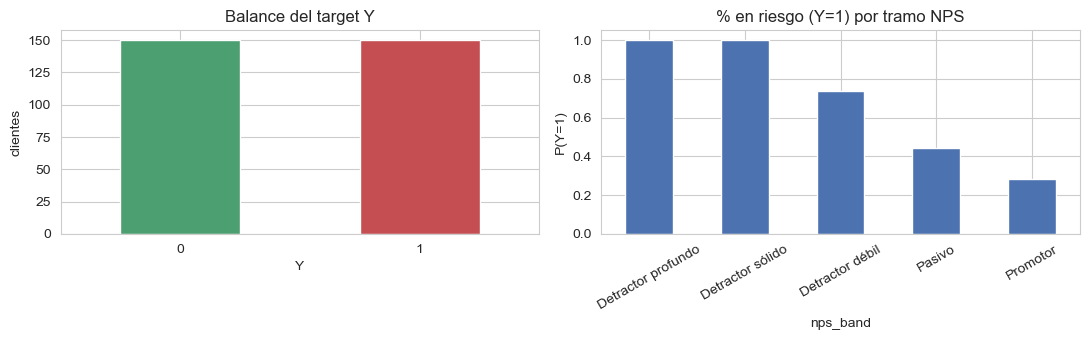

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df["Y"].value_counts().sort_index().plot.bar(ax=ax[0], color=["#4c9f70", "#c44e52"], rot=0)
ax[0].set_title("Balance del target Y"); ax[0].set_xlabel("Y"); ax[0].set_ylabel("clientes")
grad["pct_Y1"].plot.bar(ax=ax[1], color="#4c72b0", rot=30)
ax[1].set_title("% en riesgo (Y=1) por tramo NPS"); ax[1].set_ylabel("P(Y=1)")
plt.tight_layout(); plt.show()

## 4. Feature engineering y prevención de *leakage*

**Excluimos como predictores todo lo que define `Y`.** Si dejáramos esas variables, el modelo
"haría trampa" reconstruyendo la fórmula del score en lugar de aprender señales independientes:

- `trust_level`, `switch_reasons` y **todos** sus derivados (`IF`, `risk_score`, `nps_band`,
  conteos/binarios de razones).
- `marca_temporal` (sello de tiempo, sin valor predictivo).
- `diff_uses` y `main_factor` (texto libre, alto missing e idiosincrático).

**Features finales (16):** 5 conteos de multi-select + 4 numéricas + 2 ordinales + 5 categóricas.

> Nota honesta: `uses_fintech` resulta **casi constante** (solo 1 encuestado responde "Ninguna"),
> así que aporta poca señal; se conserva por completitud del diseño.

In [7]:
# Conteos de columnas multi-select
df["n_fintech_concerns"] = count_multi(df["fintech_concerns"])
df["n_app_frustrations"] = count_multi(df["app_frustrations"])
df["n_app_likes"]        = count_multi(df["app_likes"])
df["n_security_concerns"] = count_multi(df["security_concerns"])
df["n_benefits_valued"]  = count_multi(df["benefits_valued"])

# Binaria: ¿usa alguna fintech?
df["uses_fintech"] = df["fintechs_used"].apply(
    lambda s: 0 if (pd.isna(s) or "Ninguna" in str(s) or str(s).strip() == "") else 1)

X = df[FEATURES].copy()
y = df["Y"].copy()

print(f"{len(FEATURES)} features:")
print("  Numéricas :", NUMERIC_FEATURES)
print("  Ordinales :", ORDINAL_FEATURES)
print("  Categóricas:", CATEGORICAL_FEATURES)
print("\nuses_fintech (casi constante):", df["uses_fintech"].value_counts().to_dict())

16 features:
  Numéricas : ['n_fintech_concerns', 'n_app_frustrations', 'n_app_likes', 'n_security_concerns', 'n_benefits_valued', 'n_apps', 'transaction_difficulty', 'branch_importance', 'uses_fintech']
  Ordinales : ['age', 'income']
  Categóricas: ['knows_fintech', 'inst_type', 'prefer_fintech', 'support_pref', 'main_bank']

uses_fintech (casi constante): {1: 299, 0: 1}


## 5. Preprocesamiento y split

Un `ColumnTransformer` aplica el tratamiento correcto a cada tipo de columna:

- **Numéricas**: imputación por mediana + `StandardScaler`.
- **Ordinales**: imputación por moda + `OrdinalEncoder` con orden explícito + `StandardScaler`.
- **Categóricas**: imputación constante `'NA'` + `OneHotEncoder(handle_unknown='ignore')`.

Split estratificado **80/20** con `random_state=42` para preservar el balance de `Y`.

In [8]:
numeric_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                         ("sc", StandardScaler())])
ordinal_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(categories=[AGE_ORDER, INCOME_ORDER],
                           handle_unknown="use_encoded_value", unknown_value=-1)),
    ("sc", StandardScaler())])
categorical_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="constant", fill_value="NA")),
    ("oh", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC_FEATURES),
    ("ord", ordinal_pipe, ORDINAL_FEATURES),
    ("cat", categorical_pipe, CATEGORICAL_FEATURES)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {len(y_train)} filas, balance Y={y_train.mean():.3f}")
print(f"Test : {len(y_test)} filas, balance Y={y_test.mean():.3f}")

Train: 240 filas, balance Y=0.500
Test : 60 filas, balance Y=0.500


## 6. Modelado y comparación (5-fold CV)

Tres candidatos en pipelines **idénticos salvo el clasificador**: Regresión Logística, Random
Forest y XGBoost. Todos manejan el balance de clases (`class_weight='balanced'`; `scale_pos_weight`
en XGBoost). Comparamos con `StratifiedKFold(5)` sobre *train* reportando ROC-AUC, F1, precisión y
recall (media ± std). **Elegimos al ganador por ROC-AUC.**

In [9]:
models = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight="balanced",
                                 random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(class_weight="balanced",
                                           random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE,
                             scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["roc_auc", "f1", "precision", "recall"]

rows = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name,
                 **{m: f"{res['test_'+m].mean():.3f} ± {res['test_'+m].std():.3f}" for m in scoring},
                 "_auc": res["test_roc_auc"].mean()})

cv_table = pd.DataFrame(rows).set_index("model")
winner = cv_table["_auc"].idxmax()
print("Comparación 5-fold CV (sobre train):")
display(cv_table.drop(columns="_auc"))
print("🏆 Ganador por ROC-AUC:", winner)

Comparación 5-fold CV (sobre train):


,roc_auc,f1,precision,recall
model,,,,
LogReg,0.705 ± 0.085,0.658 ± 0.077,0.667 ± 0.076,0.650 ± 0.086
RandomForest,0.665 ± 0.046,0.606 ± 0.027,0.615 ± 0.053,0.600 ± 0.033
XGBoost,0.627 ± 0.046,0.595 ± 0.077,0.595 ± 0.069,0.600 ± 0.101


🏆 Ganador por ROC-AUC: LogReg


## 7. Tuning del ganador (`GridSearchCV`, 5-fold, optimizando ROC-AUC)

Afinamos solo al modelo ganador sobre *train* y reportamos sus mejores hiperparámetros y score CV.

In [10]:
grids = {
    "LogReg": {"clf__C": [0.01, 0.1, 1, 10]},
    "RandomForest": {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 5, 10],
                     "clf__min_samples_leaf": [1, 3]},
    "XGBoost": {"clf__n_estimators": [200, 400], "clf__max_depth": [2, 3, 4],
                "clf__learning_rate": [0.05, 0.1]},
}
win_pipe = Pipeline([("prep", preprocess), ("clf", models[winner])])
gs = GridSearchCV(win_pipe, grids[winner], scoring="roc_auc", cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)
best = gs.best_estimator_

print("Mejores hiperparámetros:", gs.best_params_)
print(f"ROC-AUC CV del mejor modelo: {gs.best_score_:.3f}")

Mejores hiperparámetros: {'clf__C': 0.01}
ROC-AUC CV del mejor modelo: 0.713


## 8. Evaluación en el holdout intacto (20%)

Recién aquí tocamos el conjunto de test. Reportamos métricas, matriz de confusión, curvas ROC /
Precision-Recall, calibración, una mini-auditoría de *fairness* por subgrupos y la
interpretabilidad con SHAP.

> El holdout son ~60 personas: las métricas por subgrupo serán **ruidosas**. Lo tratamos como
> diagnóstico cualitativo, no como medida fina.

In [11]:
y_pred  = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}")
print(f"F1      : {f1_score(y_test, y_pred):.3f}")
print(f"Precisión: {precision_score(y_test, y_pred):.3f}")
print(f"Recall  : {recall_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=["No riesgo (0)", "Riesgo (1)"]))

ROC-AUC : 0.650
F1      : 0.588
Precisión: 0.714
Recall  : 0.500

               precision    recall  f1-score   support

No riesgo (0)       0.62      0.80      0.70        30
   Riesgo (1)       0.71      0.50      0.59        30

     accuracy                           0.65        60
    macro avg       0.66      0.65      0.64        60
 weighted avg       0.66      0.65      0.64        60



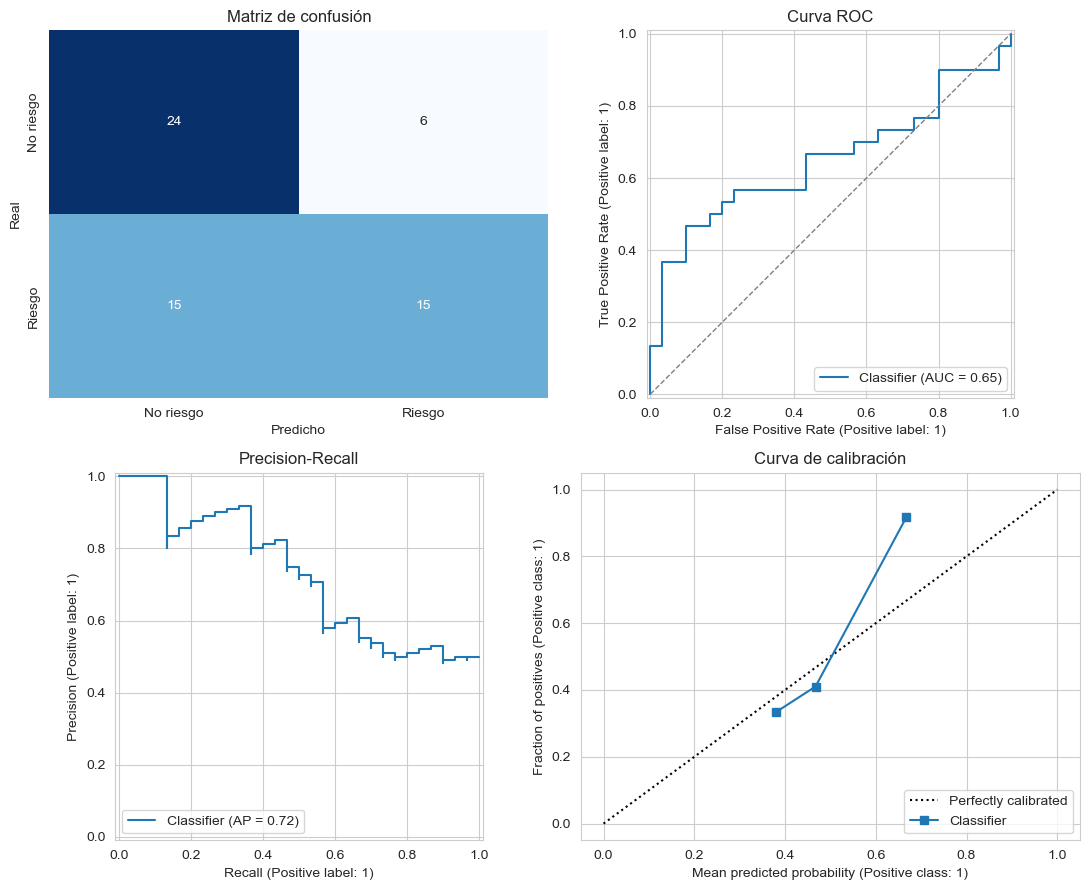

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(11, 9))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No riesgo", "Riesgo"], yticklabels=["No riesgo", "Riesgo"], ax=ax[0, 0])
ax[0, 0].set_title("Matriz de confusión"); ax[0, 0].set_xlabel("Predicho"); ax[0, 0].set_ylabel("Real")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[0, 1]); ax[0, 1].set_title("Curva ROC")
ax[0, 1].plot([0, 1], [0, 1], "--", color="grey", lw=1)
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax[1, 0]); ax[1, 0].set_title("Precision-Recall")
CalibrationDisplay.from_predictions(y_test, y_proba, n_bins=5, ax=ax[1, 1]); ax[1, 1].set_title("Curva de calibración")
plt.tight_layout(); plt.show()

### 8a. Mini-auditoría de *fairness* por subgrupos

ROC-AUC por subgrupos de `age` e `income` (filtramos subgrupos con n<5 o sin ambas clases).
Con ~60 personas en holdout, estas cifras son **muy ruidosas**: sirven para detectar disparidades
groseras, no para conclusiones finas.

In [13]:
test_df = X_test.copy(); test_df["Y"] = y_test.values; test_df["proba"] = y_proba
fair_rows = []
for attr in ["age", "income"]:
    for val, sub in test_df.groupby(attr):
        if len(sub) >= 5 and sub["Y"].nunique() > 1:
            fair_rows.append({"atributo": attr, "subgrupo": val, "n": len(sub),
                              "ROC_AUC": round(roc_auc_score(sub["Y"], sub["proba"]), 2)})
display(pd.DataFrame(fair_rows))
print("⚠️  n pequeños → métricas ruidosas; interpretar con cautela.")

,atributo,subgrupo,n,ROC_AUC
0,age,18-25,26,0.63
1,age,26-40,10,0.62
2,age,41-55,15,0.54
3,age,56+,9,0.88
4,income,"$10,000MXN–$20,000MXN",10,0.75
5,income,"$20,000MXN–$50,000MXN",13,0.57
6,income,"Menos de $10,000 MXN",19,0.74
7,income,"Más de $50,000MXN",15,0.39


⚠️  n pequeños → métricas ruidosas; interpretar con cautela.


### 8b. Interpretabilidad con SHAP

Top features globales por `|SHAP|` medio en el holdout, y un "reason tag" por cliente (la feature
de mayor `|SHAP|` para cada predicción).

Top 12 features por |SHAP| medio:


,mean_abs_shap
num__n_fintech_concerns,0.167015
num__n_app_frustrations,0.119441
num__transaction_difficulty,0.080992
num__n_benefits_valued,0.077761
ord__income,0.053353
cat__prefer_fintech_No,0.040496
cat__main_bank_BBVA,0.024234
num__n_app_likes,0.024052
cat__prefer_fintech_Tengo usos diferentes para Fintechs y Bancos Tradicionales,0.021702
cat__support_pref_Depende del tipo de problema,0.019064


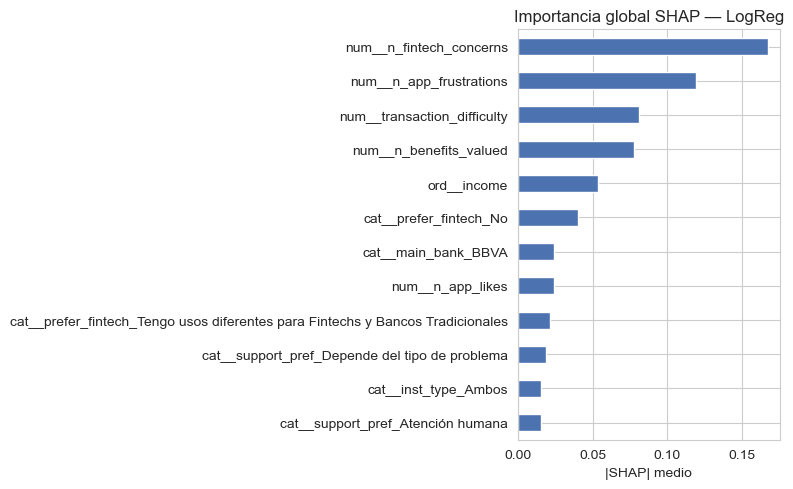

In [14]:
prep = best.named_steps["prep"]
clf  = best.named_steps["clf"]
feat_names = prep.get_feature_names_out()
X_test_t = prep.transform(X_test)
if hasattr(X_test_t, "toarray"):
    X_test_t = X_test_t.toarray()

if winner in ("RandomForest", "XGBoost"):
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(X_test_t)
    if isinstance(sv, list):
        sv = sv[1]
else:
    explainer = shap.LinearExplainer(clf, X_test_t)
    sv = explainer.shap_values(X_test_t)

imp = pd.Series(np.abs(sv).mean(axis=0), index=feat_names).sort_values(ascending=False)
print("Top 12 features por |SHAP| medio:")
display(imp.head(12).to_frame("mean_abs_shap"))

ax = imp.head(12)[::-1].plot.barh(figsize=(8, 5), color="#4c72b0")
ax.set_title(f"Importancia global SHAP — {winner}"); ax.set_xlabel("|SHAP| medio")
plt.tight_layout(); plt.show()

In [15]:
# "Reason tag" por cliente: feature de mayor |SHAP| en cada predicción del holdout
reason_tag = pd.Series([feat_names[i] for i in np.abs(sv).argmax(axis=1)], index=X_test.index)
print("Distribución del driver dominante por cliente (top 8):")
print(reason_tag.value_counts().head(8))

Distribución del driver dominante por cliente (top 8):
num__n_fintech_concerns        41
num__n_app_frustrations        10
num__transaction_difficulty     6
num__n_benefits_valued          3
dtype: int64


## 9. Resumen ejecutivo

A continuación, el cierre honesto del trabajo: modelo ganador, métricas clave en holdout, la
definición exacta de `Y` y las decisiones metodológicas justificadas.

In [16]:
print("="*70)
print("RESUMEN EJECUTIVO — Propensión al cambio bancario (Fase 1)")
print("="*70)
print(f"""
MODELO GANADOR : {winner}
  Hiperparámetros : {gs.best_params_}
  ROC-AUC CV (train) : {gs.best_score_:.3f}

MÉTRICAS EN HOLDOUT (n={len(y_test)}):
  ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}
  F1      : {f1_score(y_test, y_pred):.3f}
  Precisión: {precision_score(y_test, y_pred):.3f}
  Recall  : {recall_score(y_test, y_pred):.3f}

DEFINICIÓN DEL TARGET Y (sintético):
  risk_score = TRUST_POINTS[trust_level] + IF(Kano)
  Y = 1 si risk_score >= {RISK_THRESHOLD}, si no 0
  Balance: P(Y=1) = {df['Y'].mean():.3f}

DECISIONES JUSTIFICADAS:
  • Puntos NPS graduados: detractores 1-2 → 2.5; detractor débil (3) → 1.0;
    pasivo (4) → 0.0; promotor (5) → -1.0 (descuento por lealtad).
  • Pesos Kano: Must-Be 2.0 / Perf. financiero 1.5 / Perf. operativo 1.25 /
    Delighter 0.8 / Influencia externa 0.5 / Lealtad 0.0.
  • Umbral 2.75: produce balance 50/50 y exige "más de una señal" para riesgo.

LECTURA HONESTA:
  • Y es SINTÉTICA: el modelo reproduce una DEFINICIÓN de riesgo, no churn observado.
  • El ROC-AUC en holdout (~0.65) es modesto — esperable: excluimos a propósito las
    variables que definen Y (anti-leakage), dejando solo señales indirectas.
  • El valor está en la METODOLOGÍA de scoring (NPS + Kano), no en una predicción
    validada contra deserción real. Fase 2 debería incorporar churn observado.
""")

RESUMEN EJECUTIVO — Propensión al cambio bancario (Fase 1)

MODELO GANADOR : LogReg
  Hiperparámetros : {'clf__C': 0.01}
  ROC-AUC CV (train) : 0.713

MÉTRICAS EN HOLDOUT (n=60):
  ROC-AUC : 0.650
  F1      : 0.588
  Precisión: 0.714
  Recall  : 0.500

DEFINICIÓN DEL TARGET Y (sintético):
  risk_score = TRUST_POINTS[trust_level] + IF(Kano)
  Y = 1 si risk_score >= 2.75, si no 0
  Balance: P(Y=1) = 0.500

DECISIONES JUSTIFICADAS:
  • Puntos NPS graduados: detractores 1-2 → 2.5; detractor débil (3) → 1.0;
    pasivo (4) → 0.0; promotor (5) → -1.0 (descuento por lealtad).
  • Pesos Kano: Must-Be 2.0 / Perf. financiero 1.5 / Perf. operativo 1.25 /
    Delighter 0.8 / Influencia externa 0.5 / Lealtad 0.0.
  • Umbral 2.75: produce balance 50/50 y exige "más de una señal" para riesgo.

LECTURA HONESTA:
  • Y es SINTÉTICA: el modelo reproduce una DEFINICIÓN de riesgo, no churn observado.
  • El ROC-AUC en holdout (~0.65) es modesto — esperable: excluimos a propósito las
    variables que defin